# Filtered rate-vs-separation plots
Plots like `analysis.plot_rate_vs_separation_by_*`, limited to combinations whose estimated deadtime lower bound is 500 ns. Uses both the precomputed estimates and the raw JSONL via `DeadtimeAnalysis`.

In [1]:

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / 'src'))

from deadtime_analysis import DeadtimeAnalysis

# Data sources
EST_PATH = ROOT / 'data' / 'estimated_deadtime_all.json'
DATA_FILES = [
    ROOT / 'data' / 'combined_deadtime.jsonl',
]

# Load estimates
with EST_PATH.open() as fh:
    estimates = json.load(fh)

# Filter to combos with min_all_pulses_lower_bound_ns == 500
combos = [
    (e['pulse_rate_hz'], e['num_pulses'], e['channel_count'], e['windows'])
    for e in estimates
    if e.get('min_all_pulses_lower_bound_ns') == 500.0
]
# Deduplicate
combos = sorted(set(combos))

print(f"Filtered combos (lower bound 500ns): {len(combos)}")
for c in combos:
    print(c)

# Load full data for plotting
analysis = DeadtimeAnalysis.from_jsonl([str(p) for p in DATA_FILES])


Filtered combos (lower bound 500ns): 0


In [2]:

# Plot rate vs separation for each combo (channels view and windows view)
for rate, num_pulses, channel_count, windows in combos:
    try:
        print(f"Plotting rate={rate}, num_pulses={num_pulses}, channels={channel_count}, windows={windows}")
        # Filter by num_pulses and pulse_rate in the analysis plots
        analysis.plot_rate_vs_separation_by_channels(rate, num_pulses=int(num_pulses))
        analysis.plot_rate_vs_separation_by_windows(rate, num_pulses=int(num_pulses))
    except ValueError:
        print(f"Skipping missing data for rate={rate}, num_pulses={num_pulses}")
        continue


## Filtered rate plots using estimates (lower bound > 1000 ns)
Plots rate vs separation for representative combos drawn from `estimated_deadtime_all.json` where `min_double_lower_bound_ns > 1000`. You can adjust `EXAMPLE_COMBOS` to pin channels/windows; `None` keeps all.

Eligible combos (error bar > 1000 ns): 19


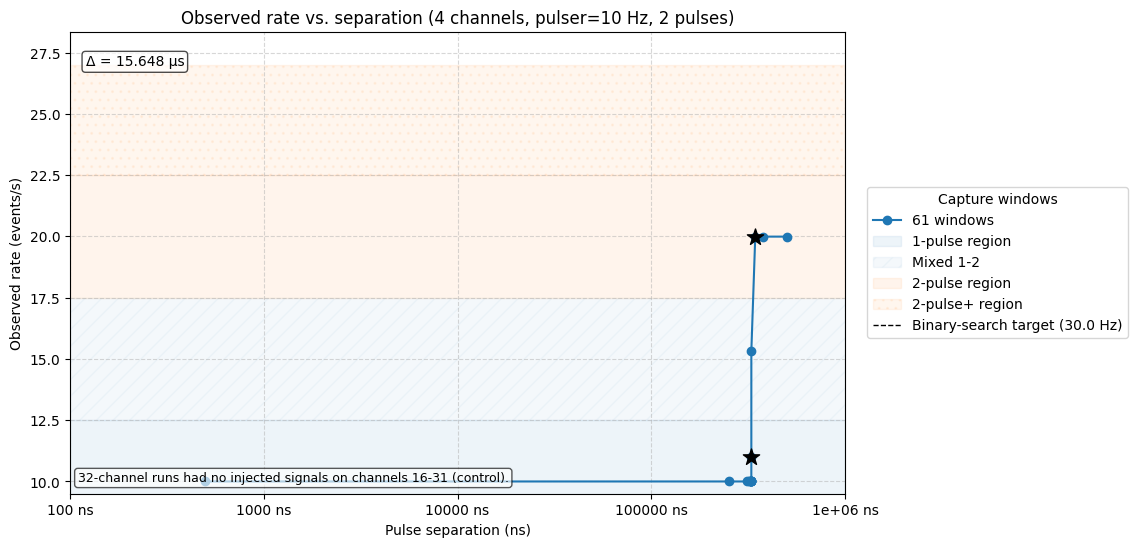

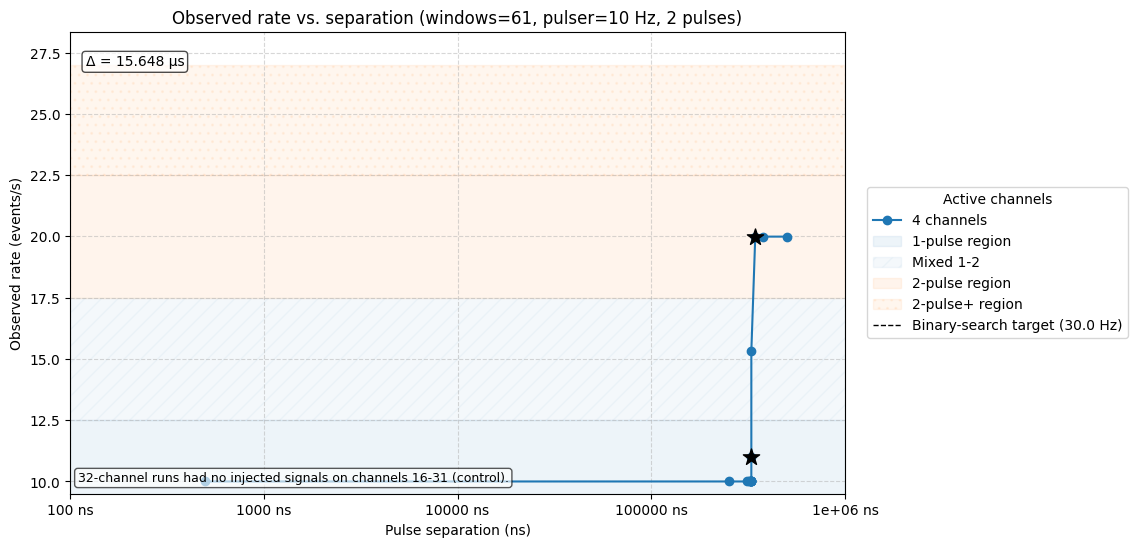

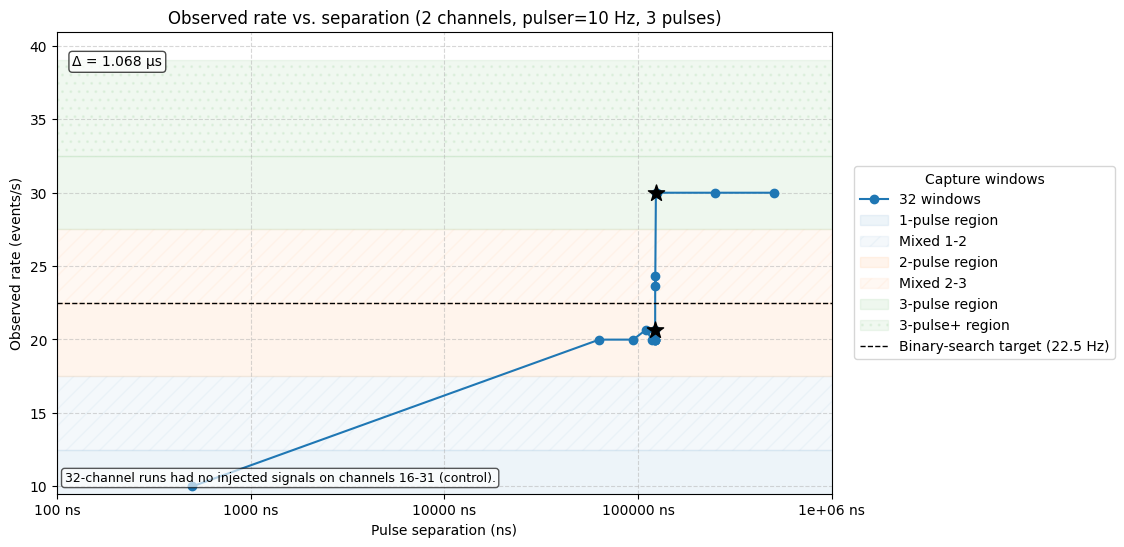

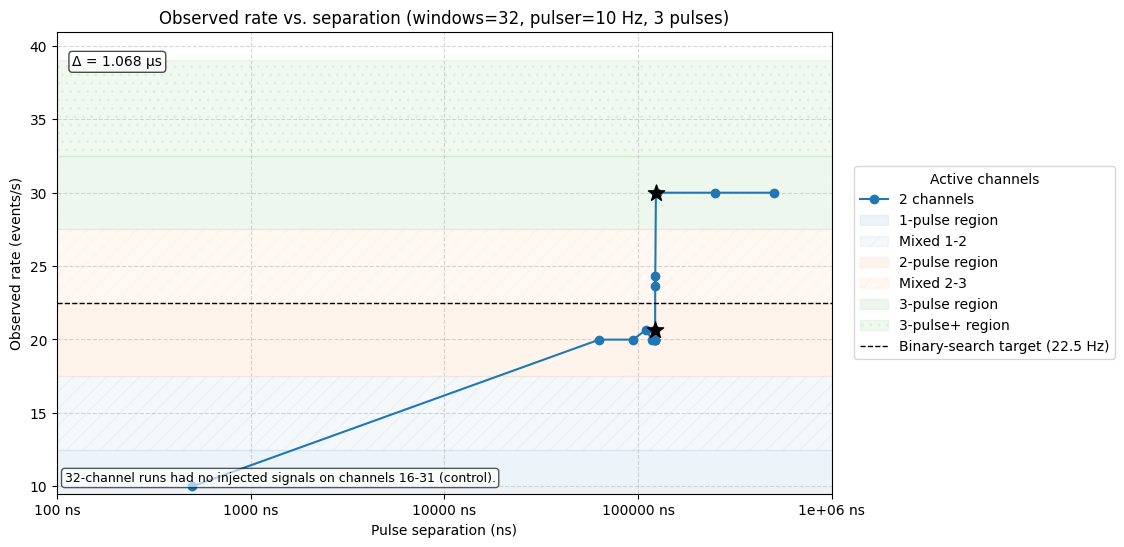

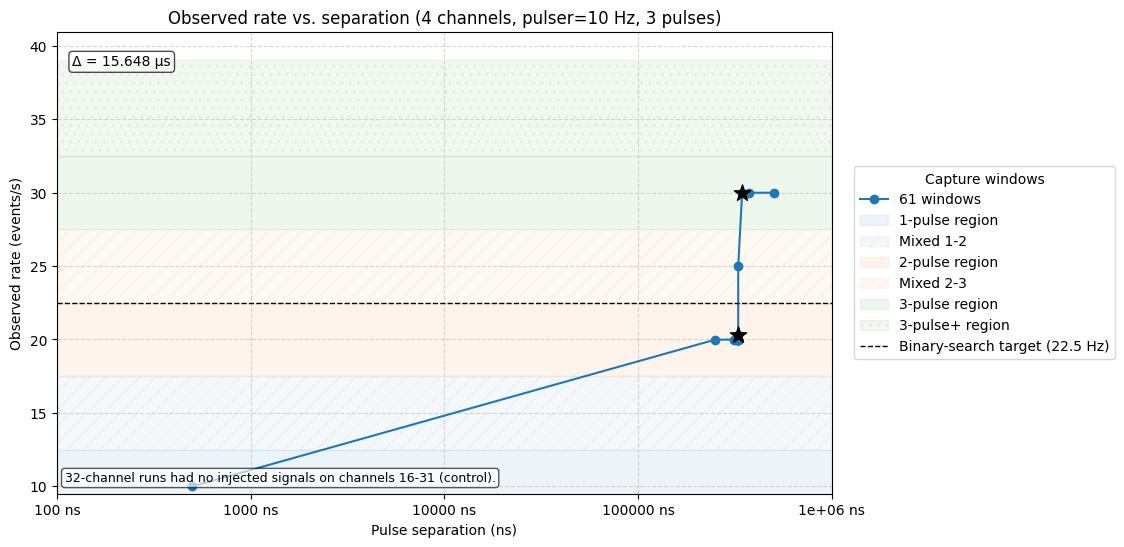

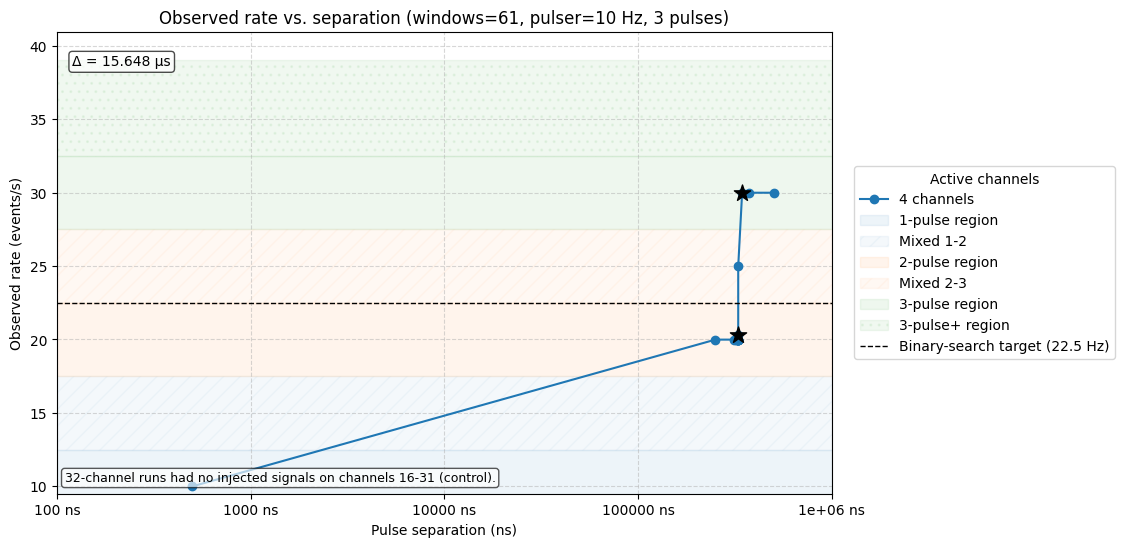

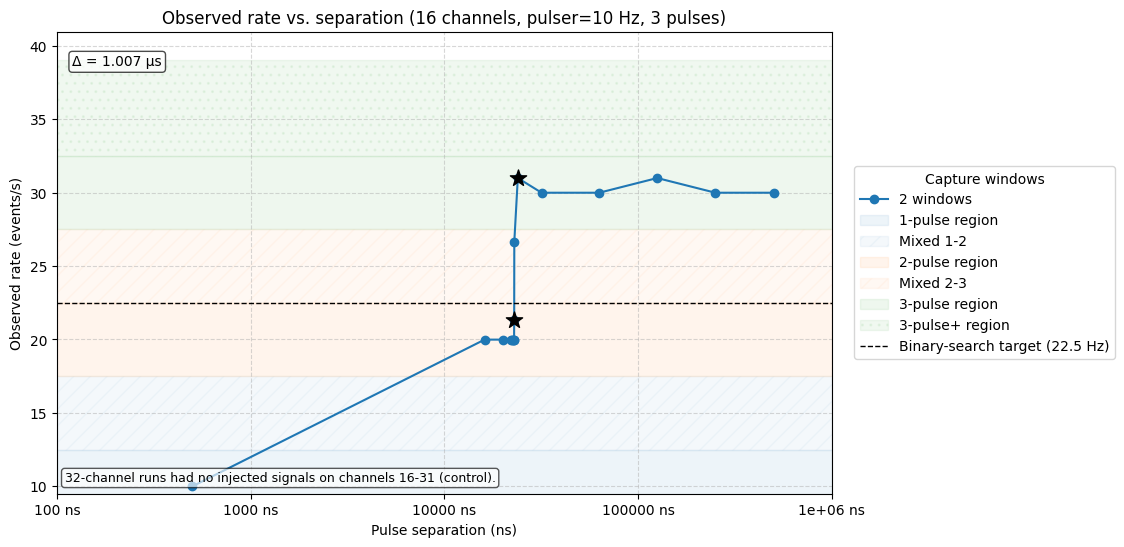

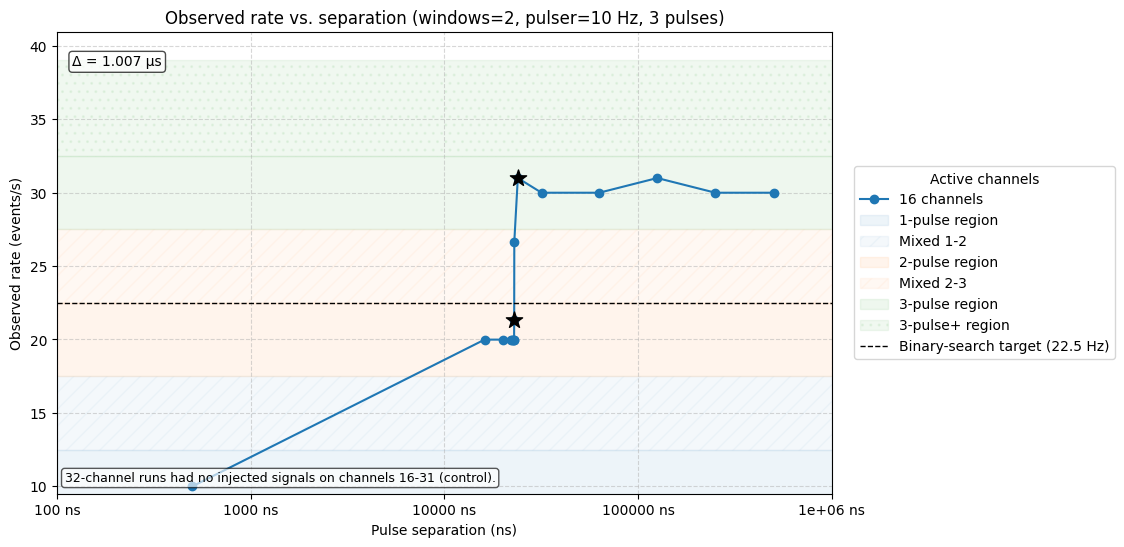

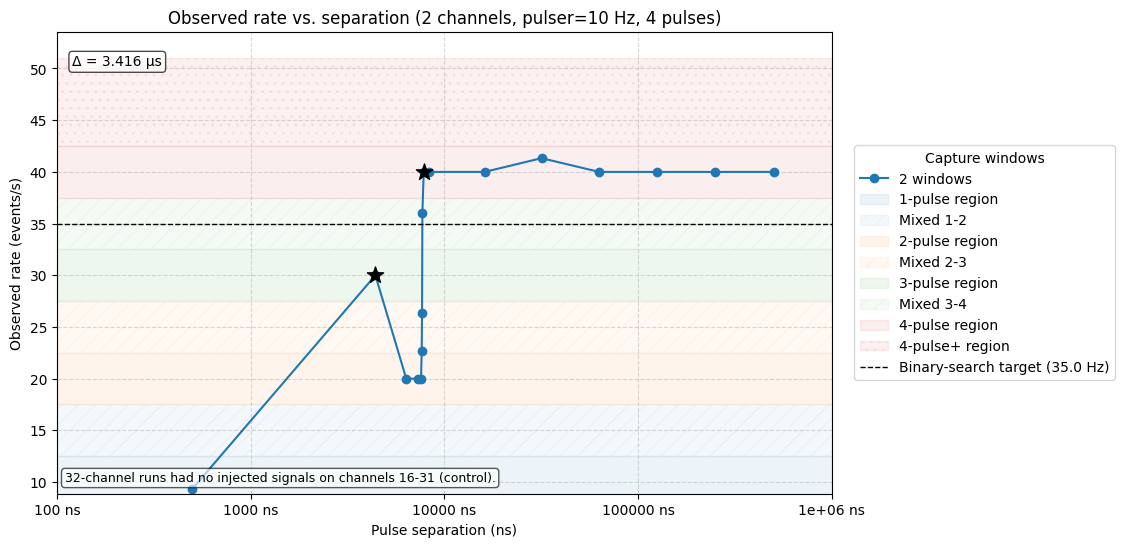

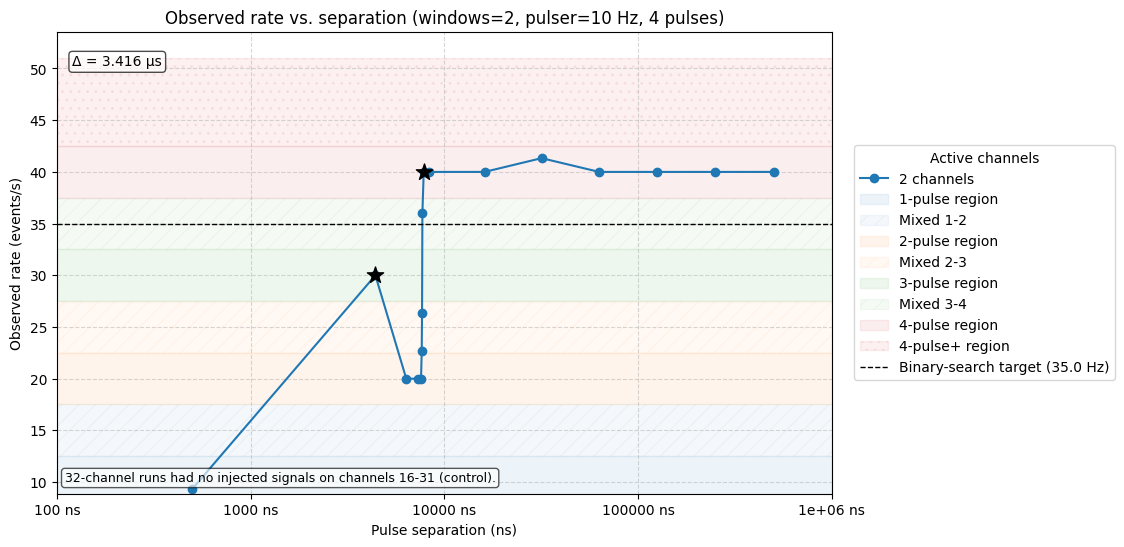

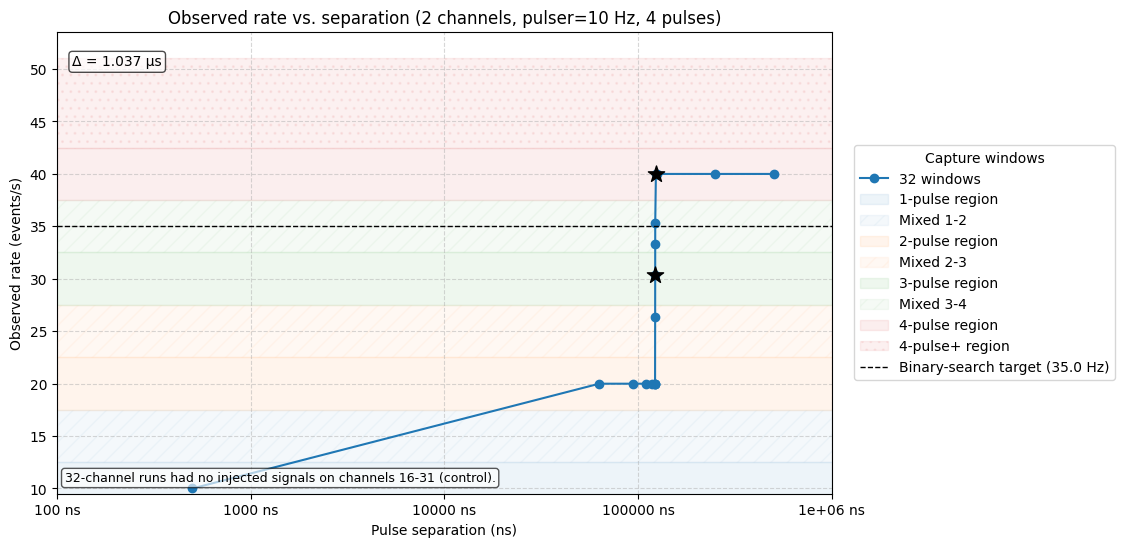

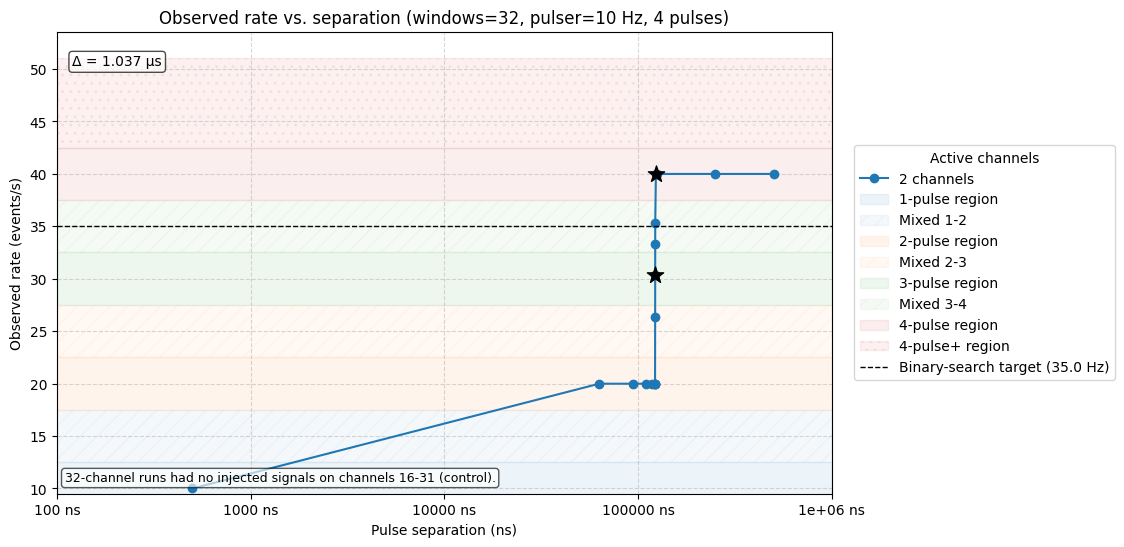

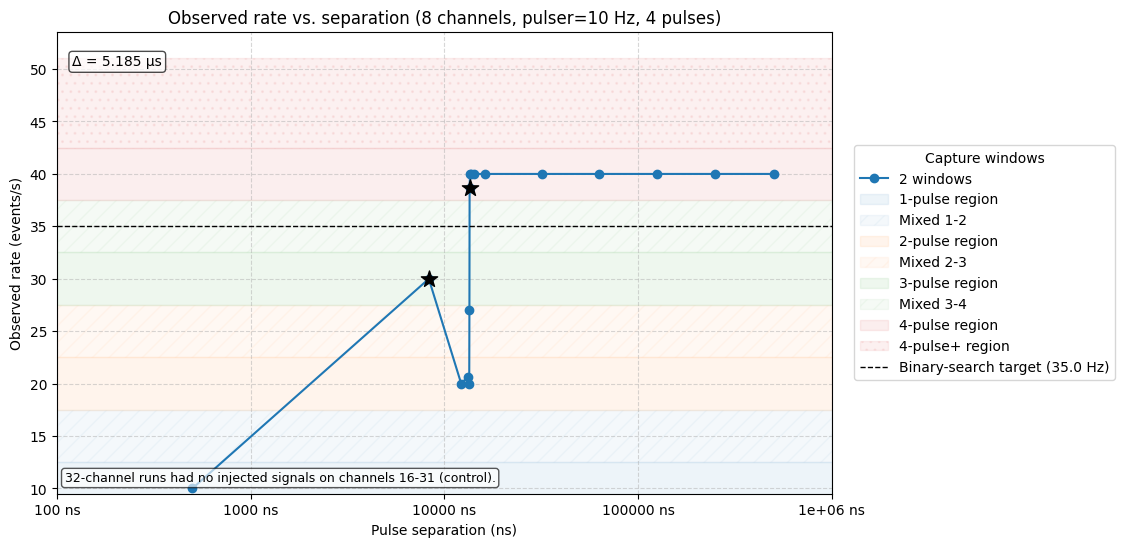

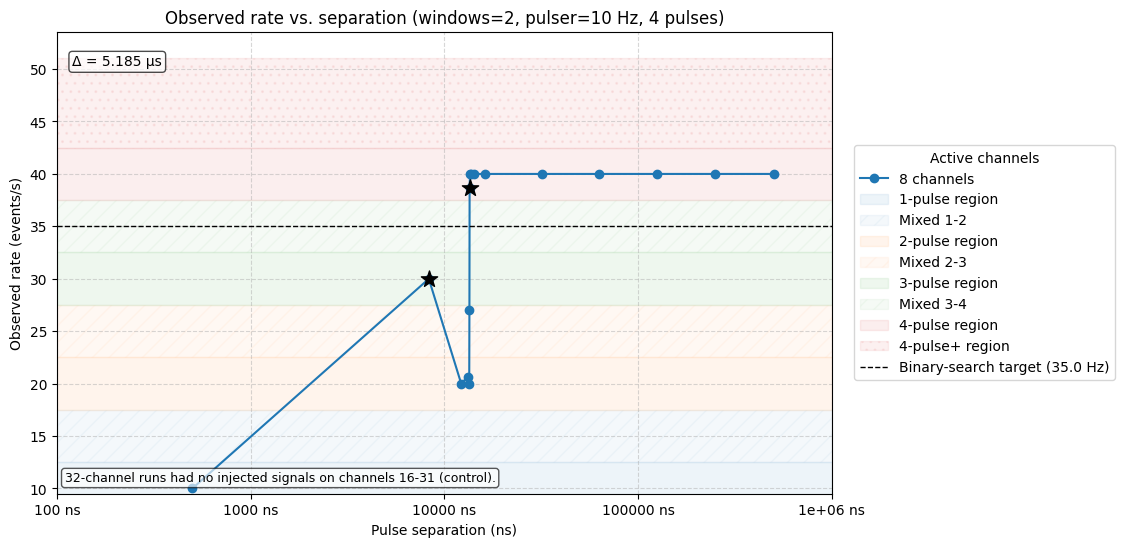

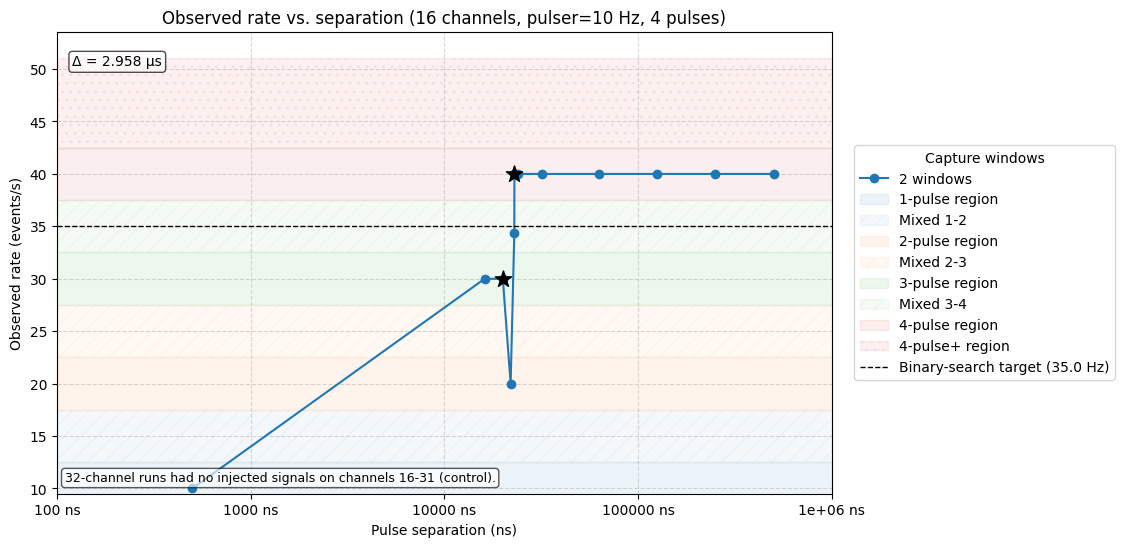

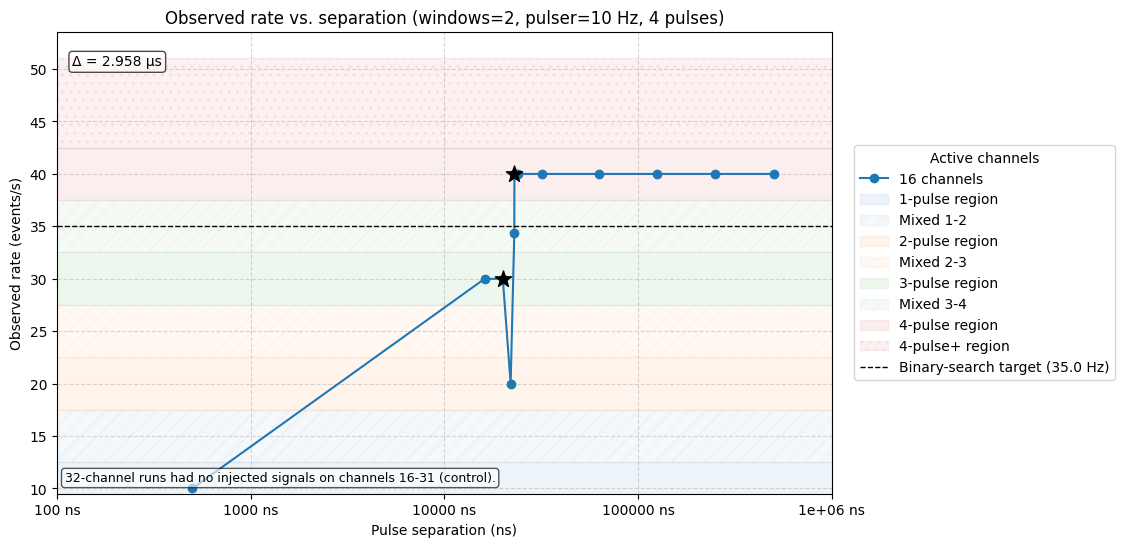

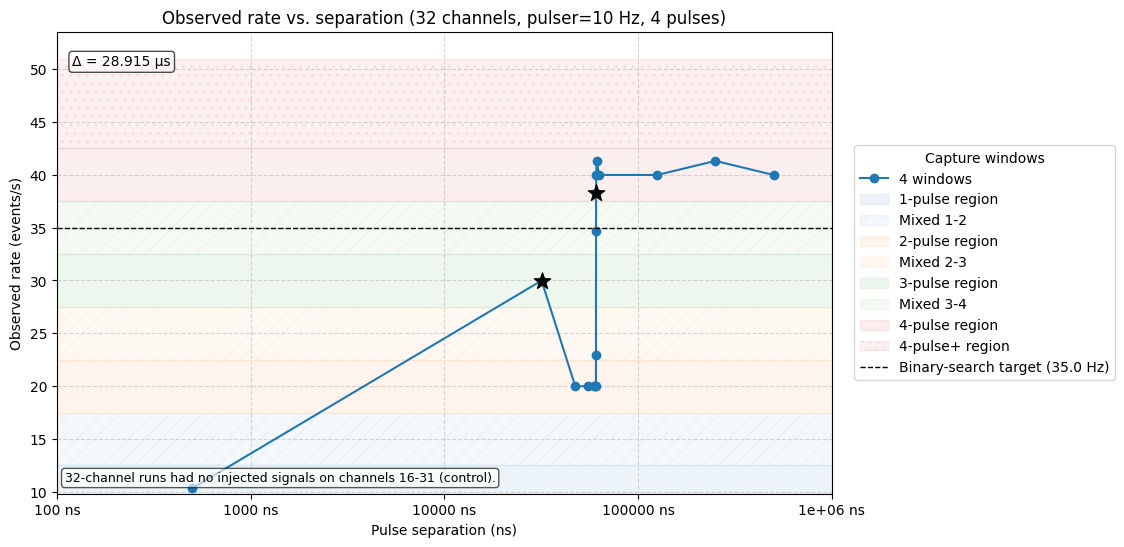

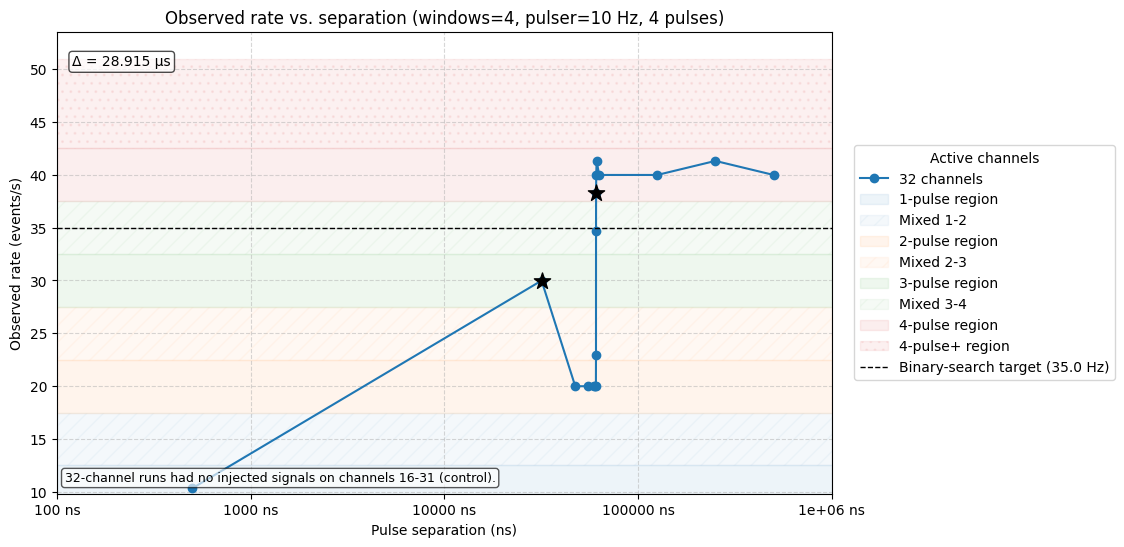

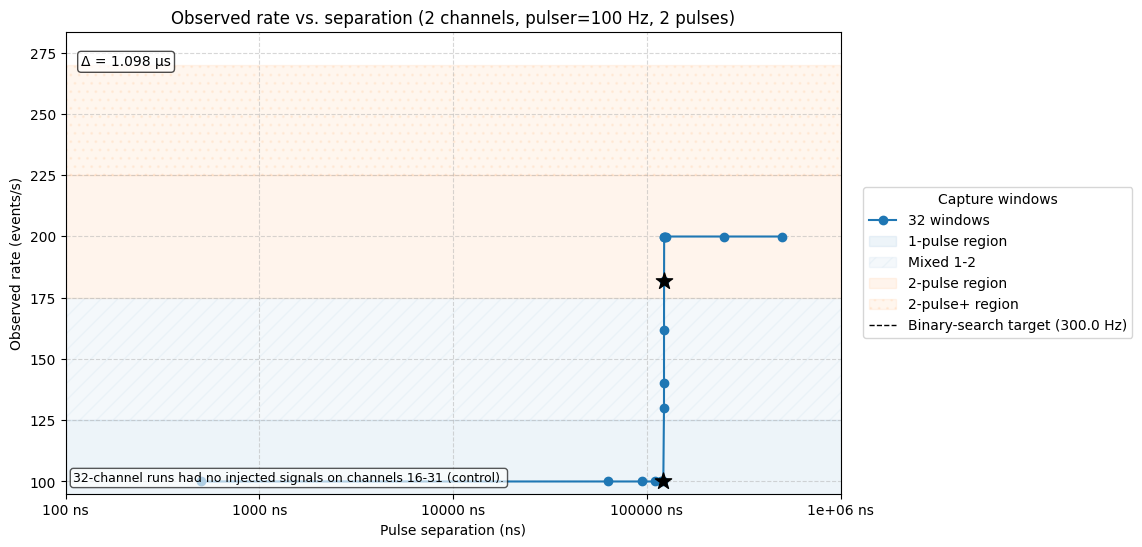

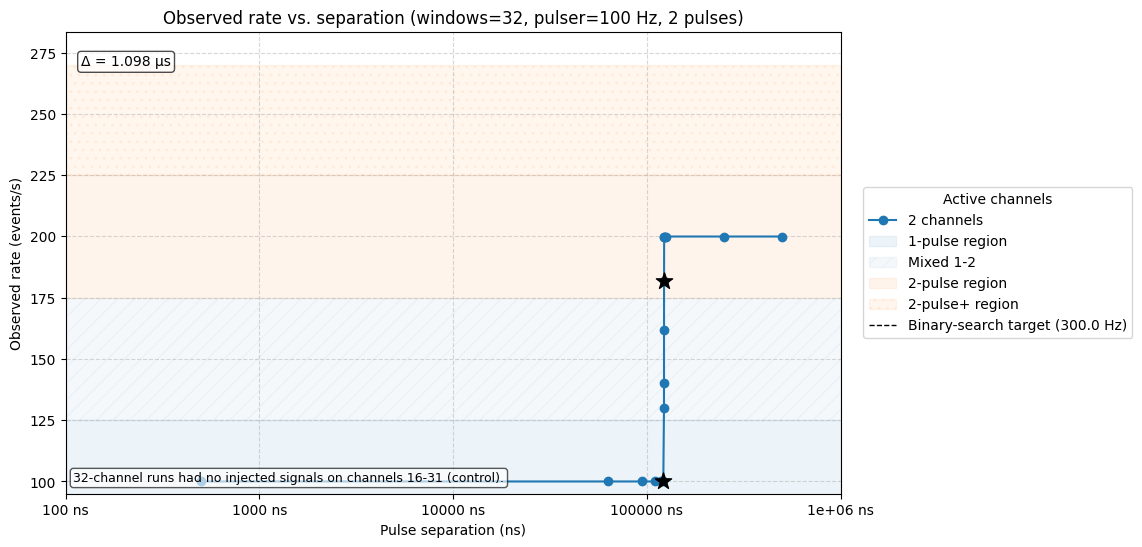

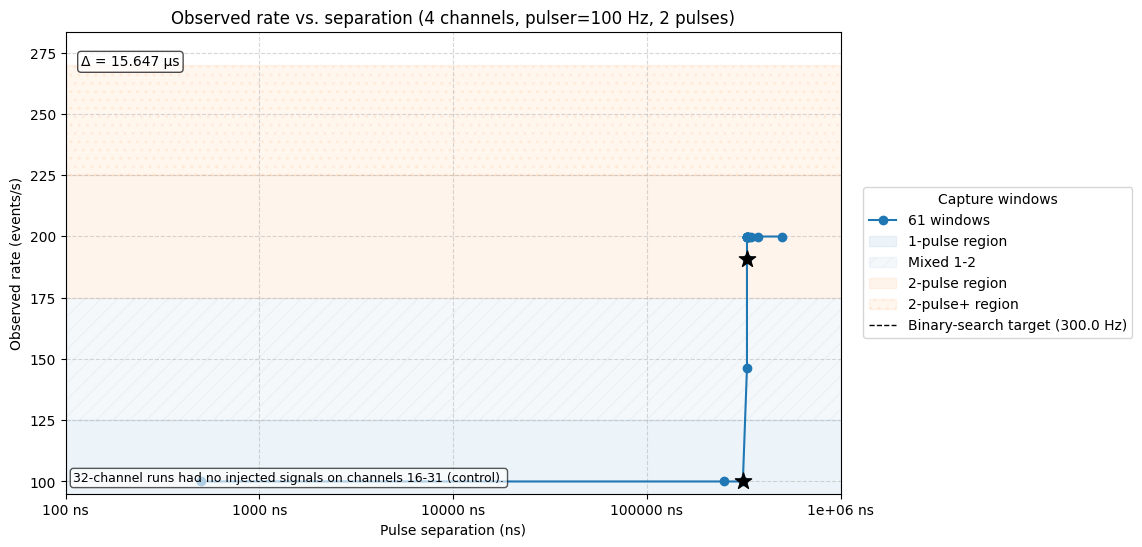

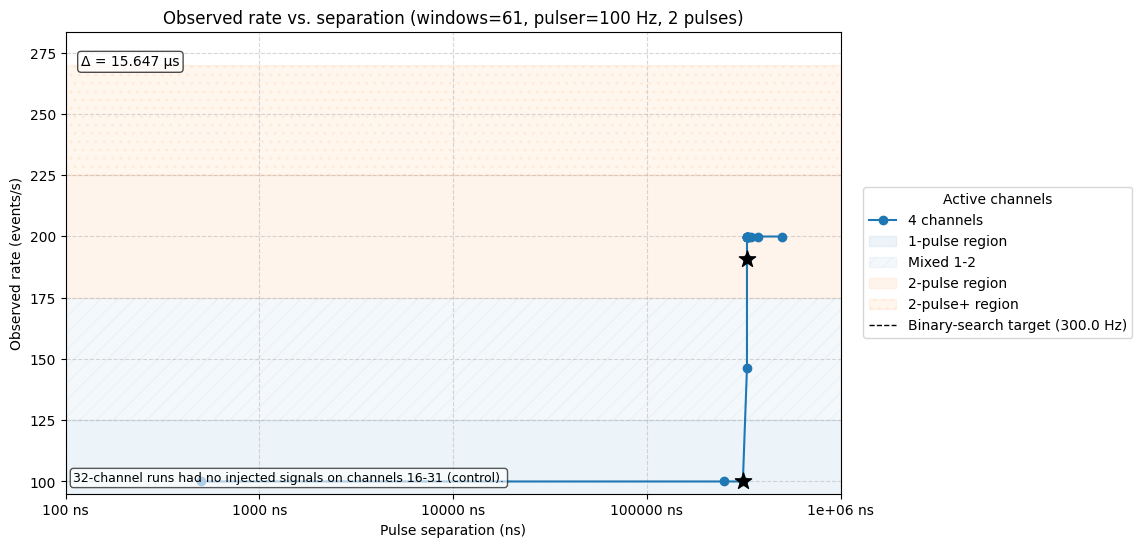

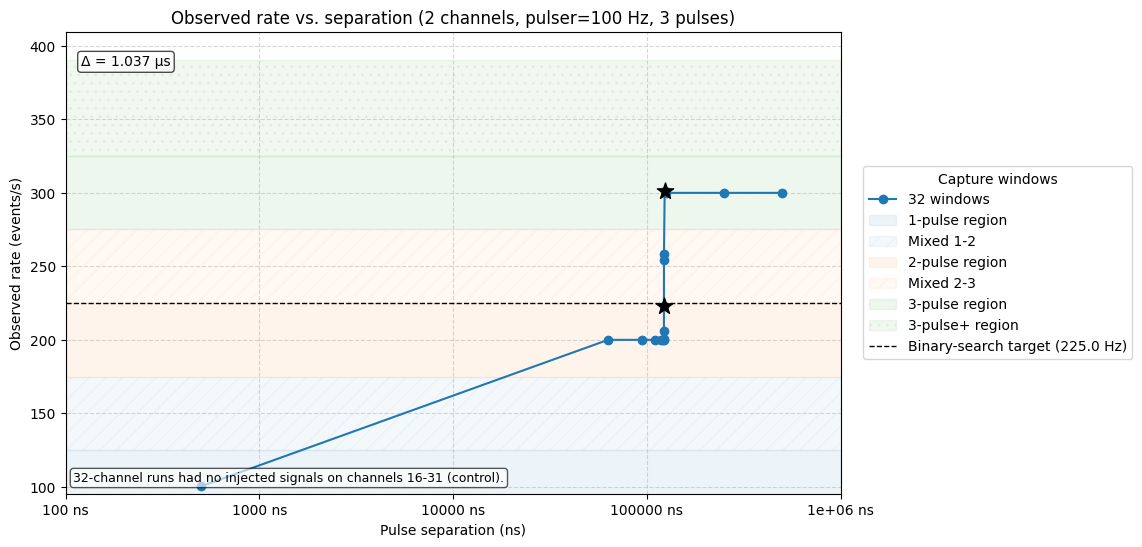

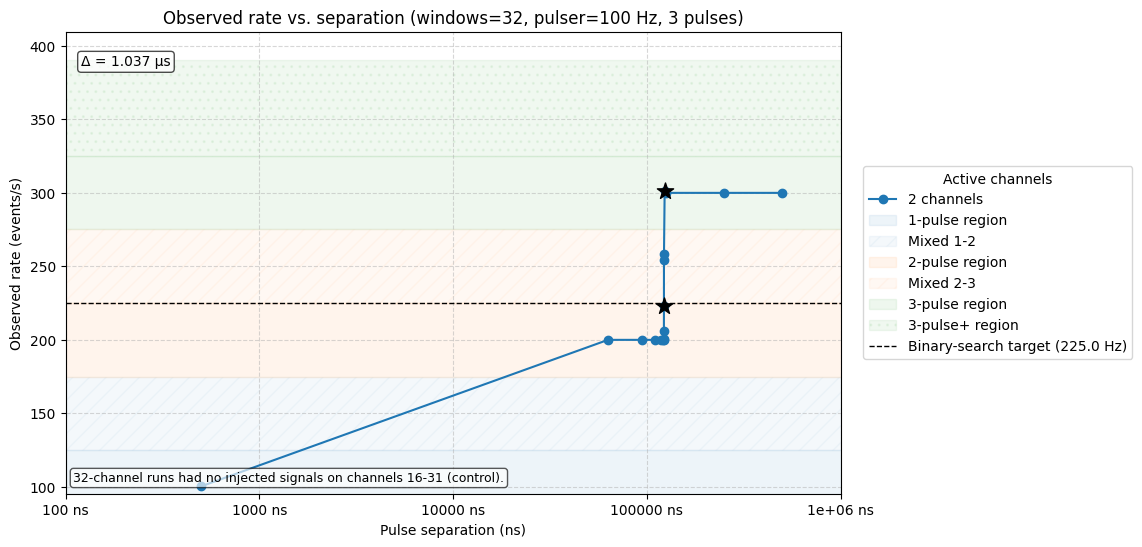

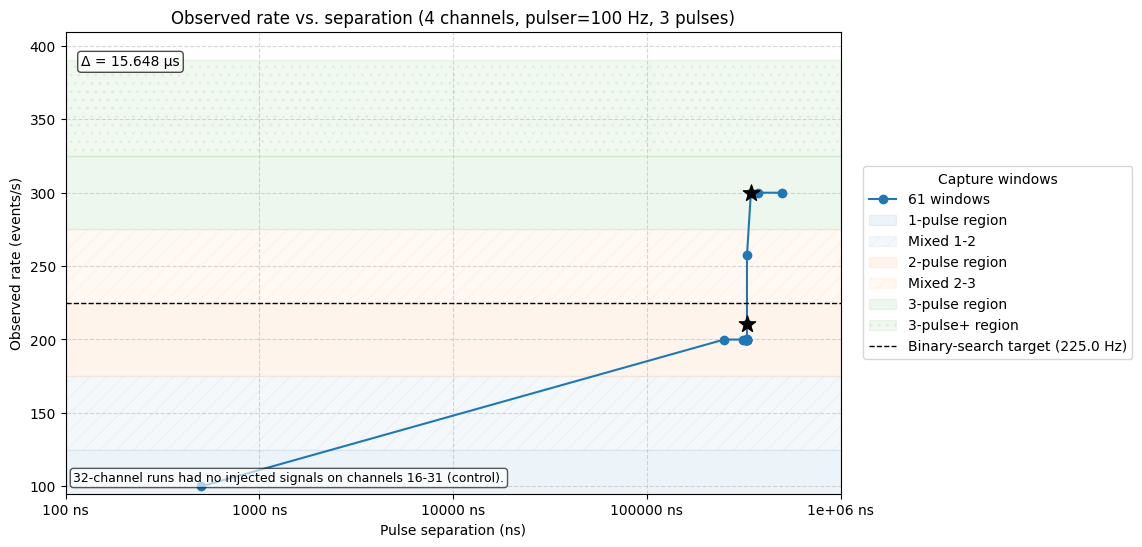

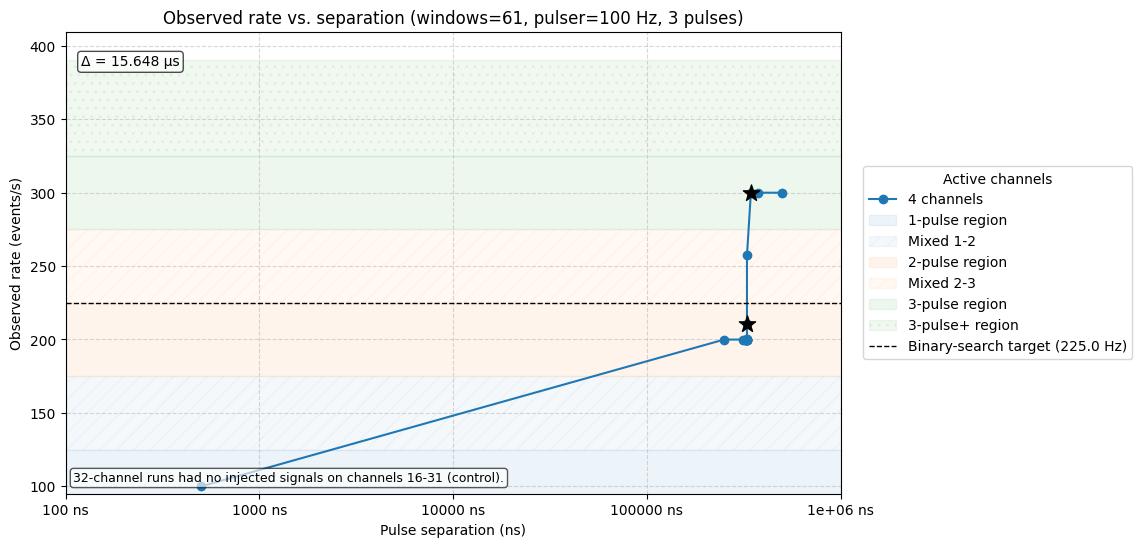

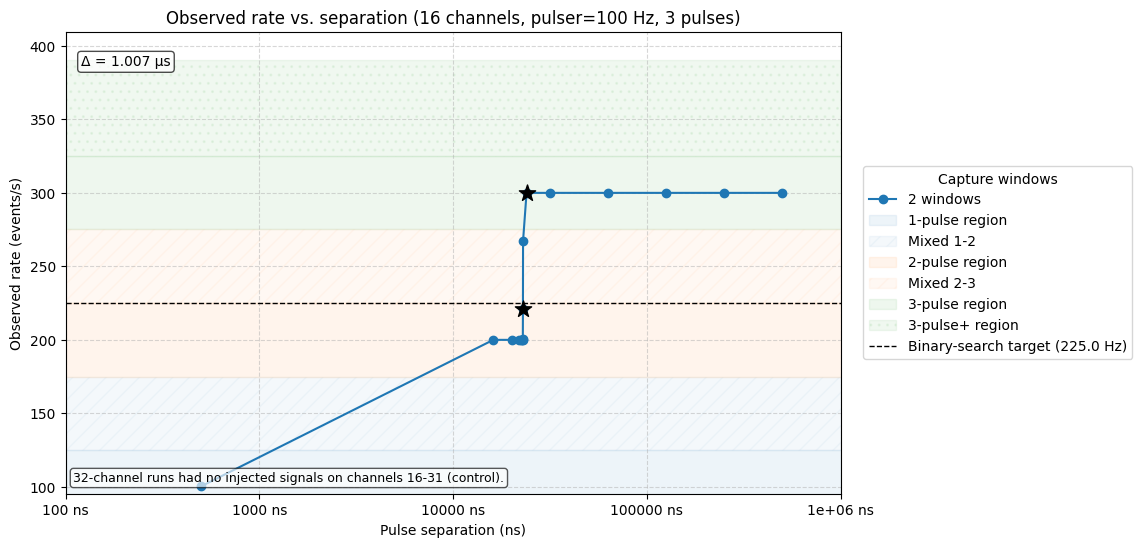

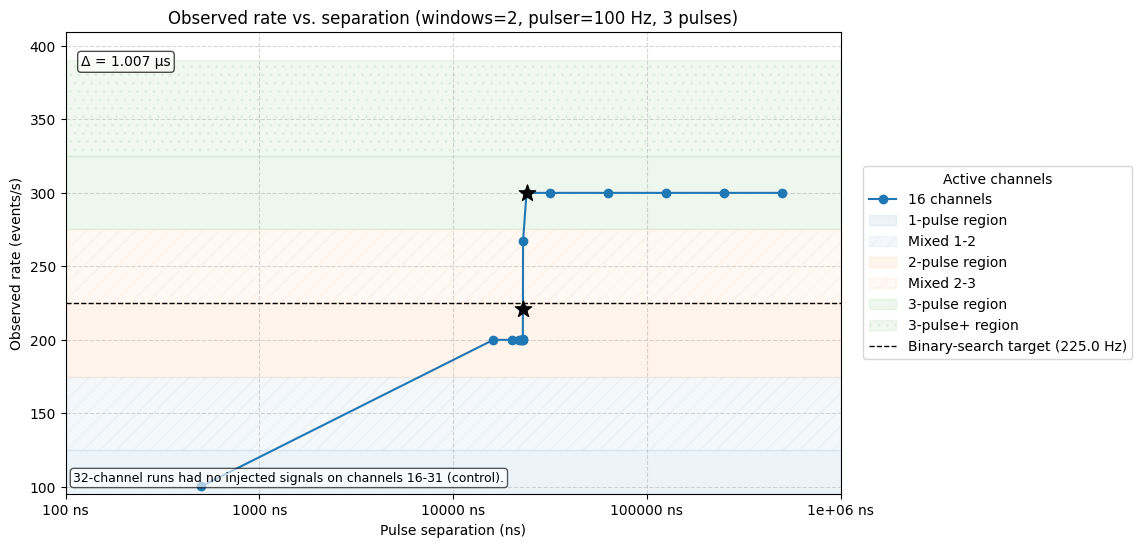

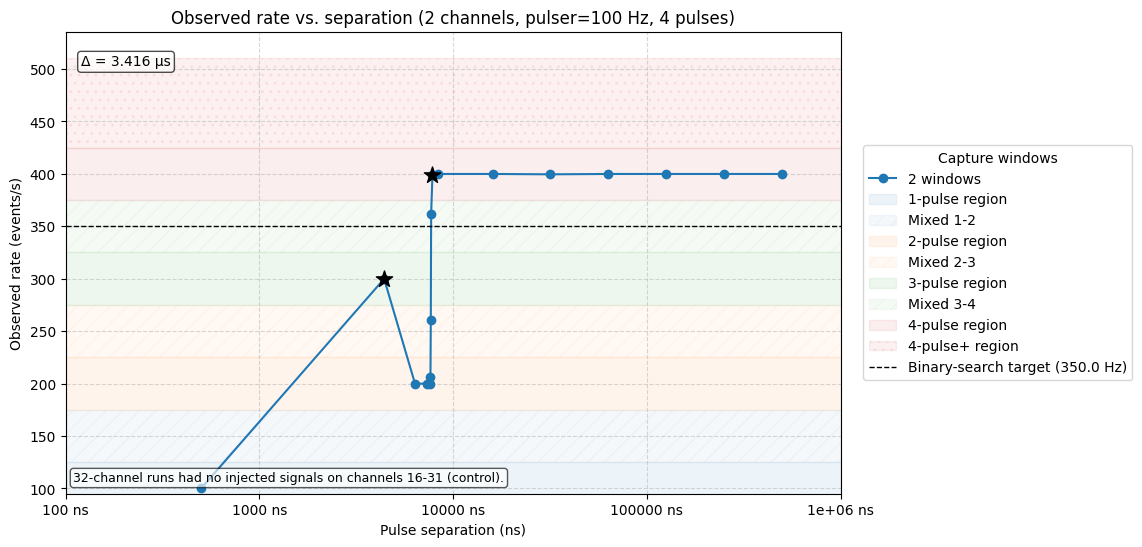

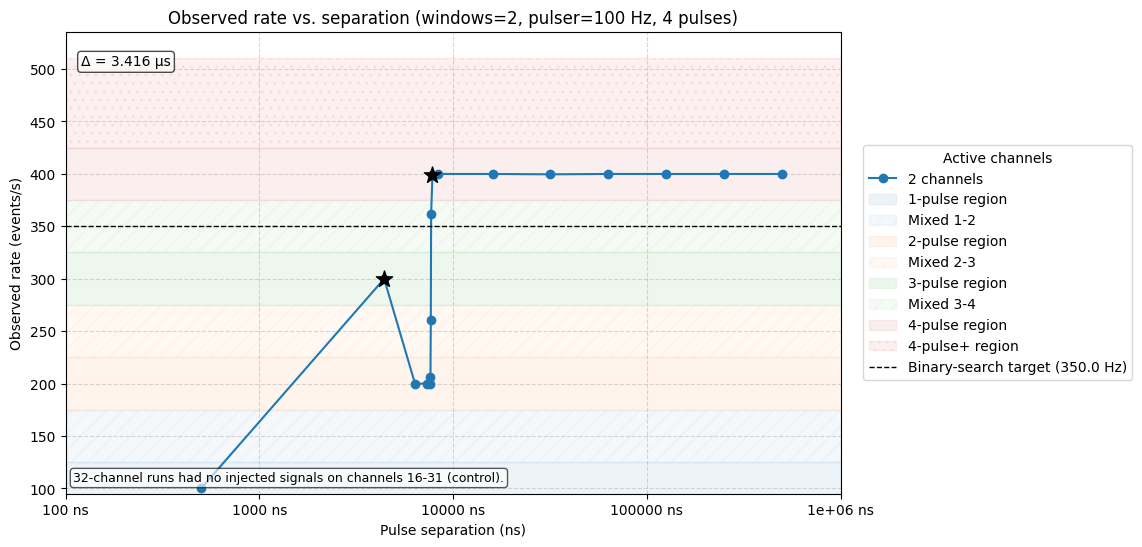

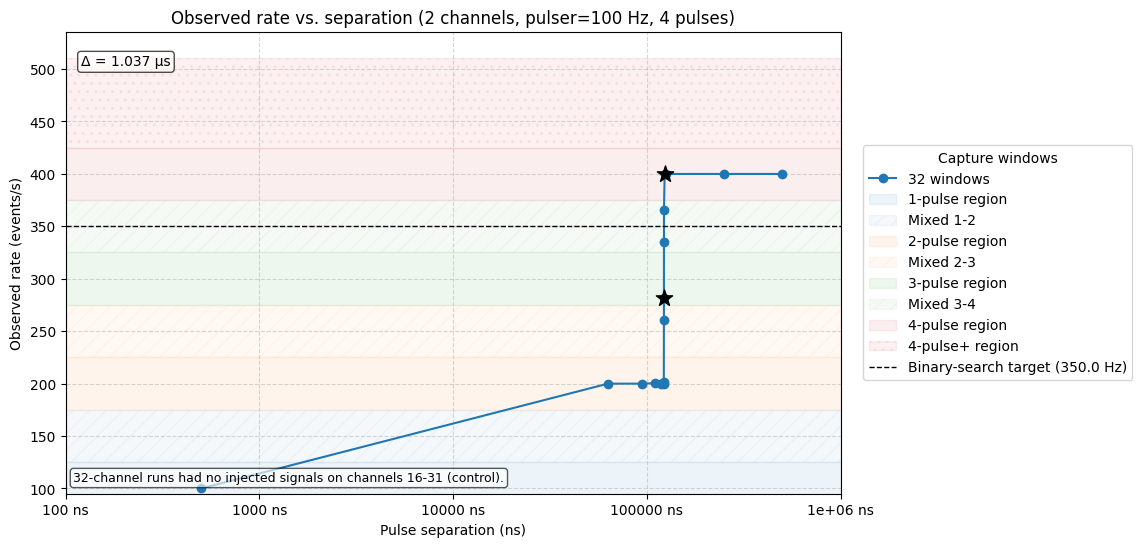

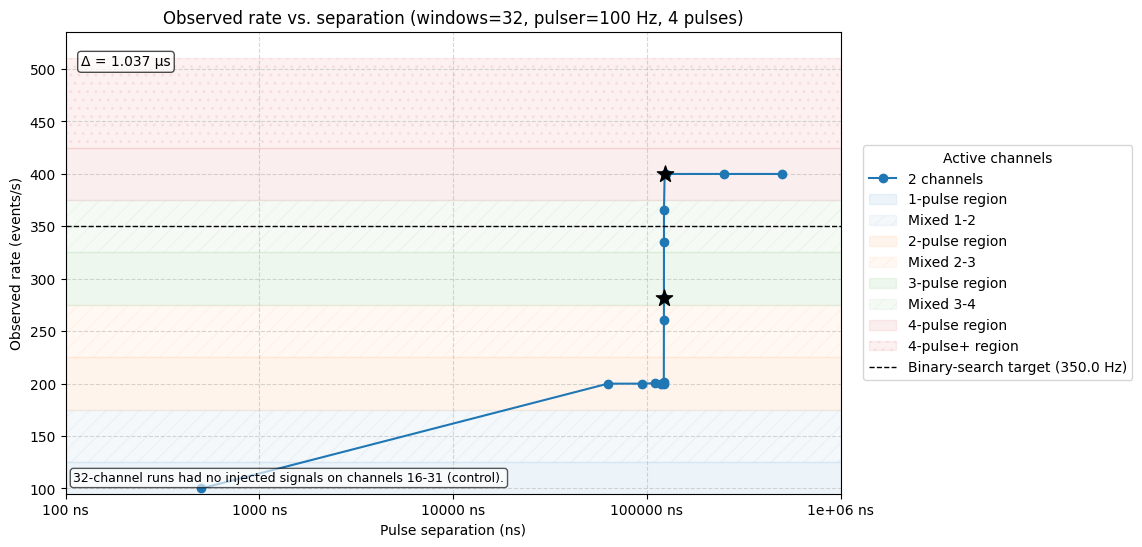

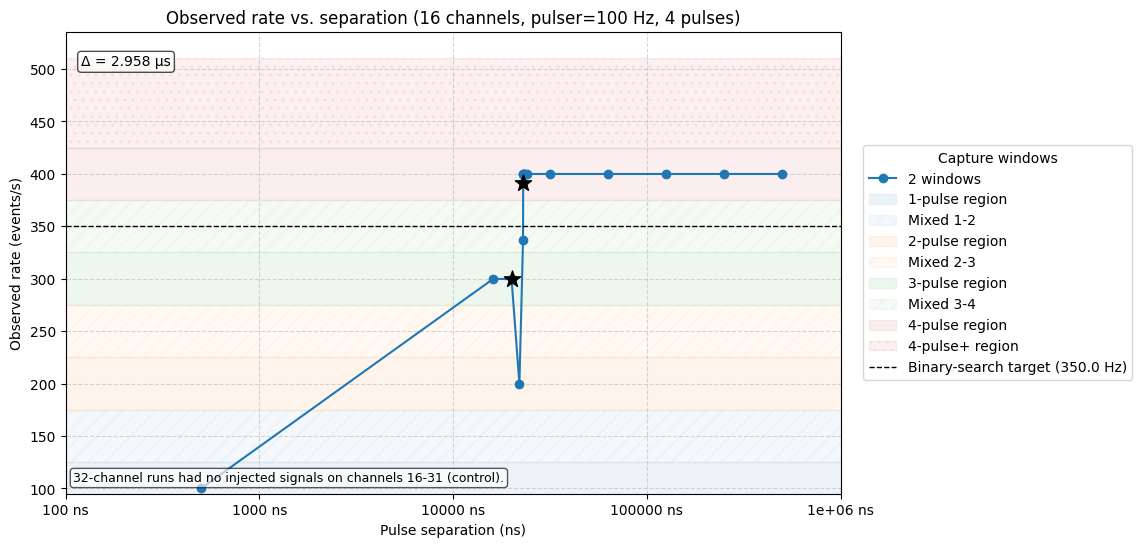

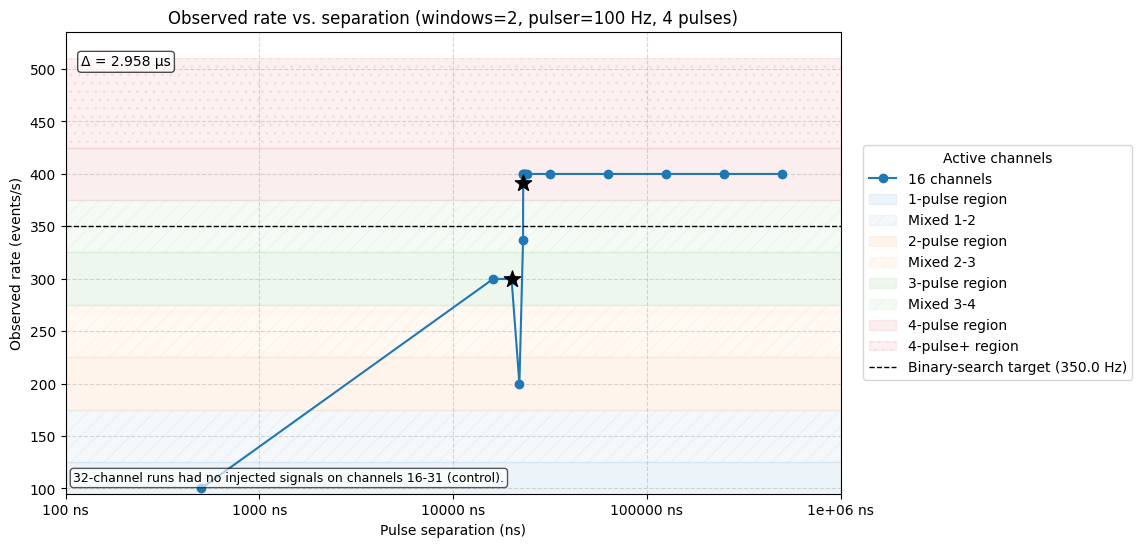

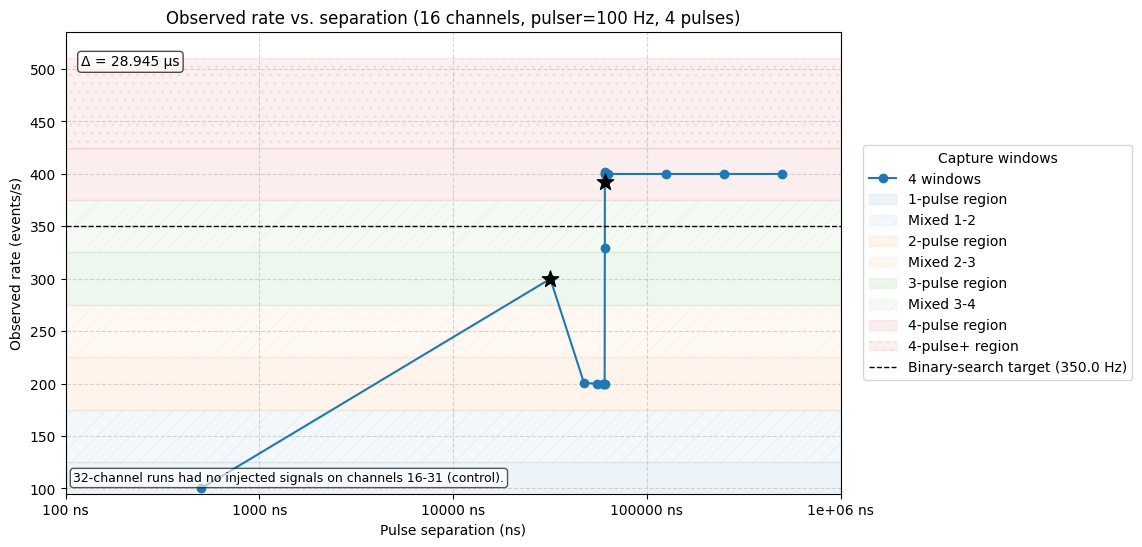

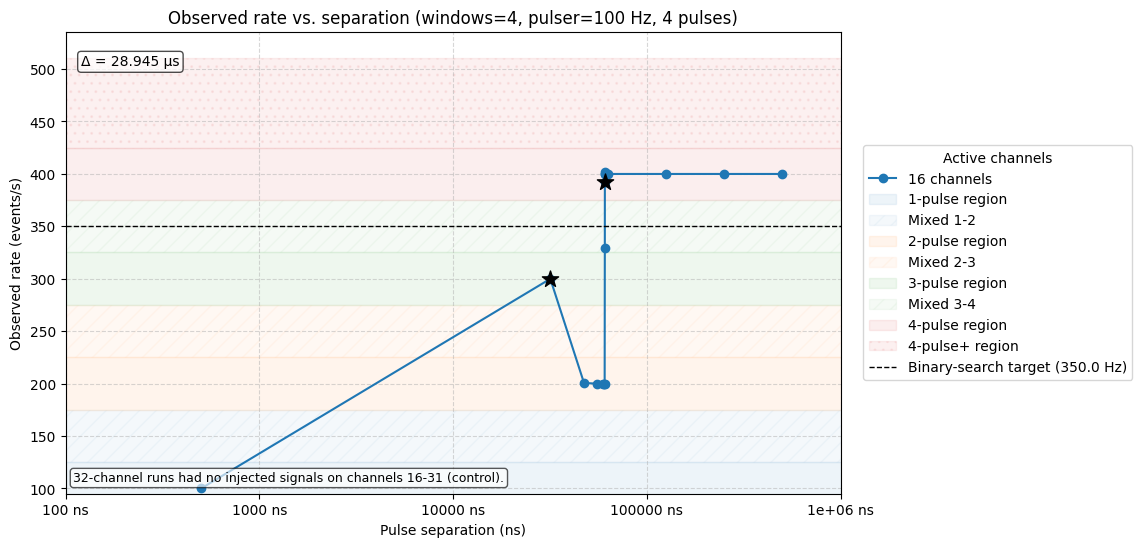

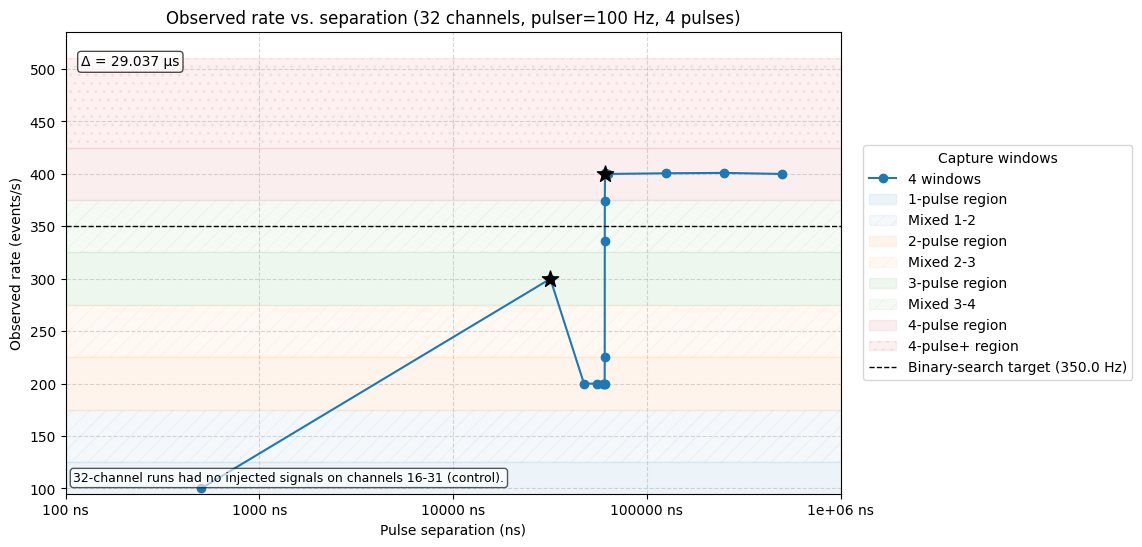

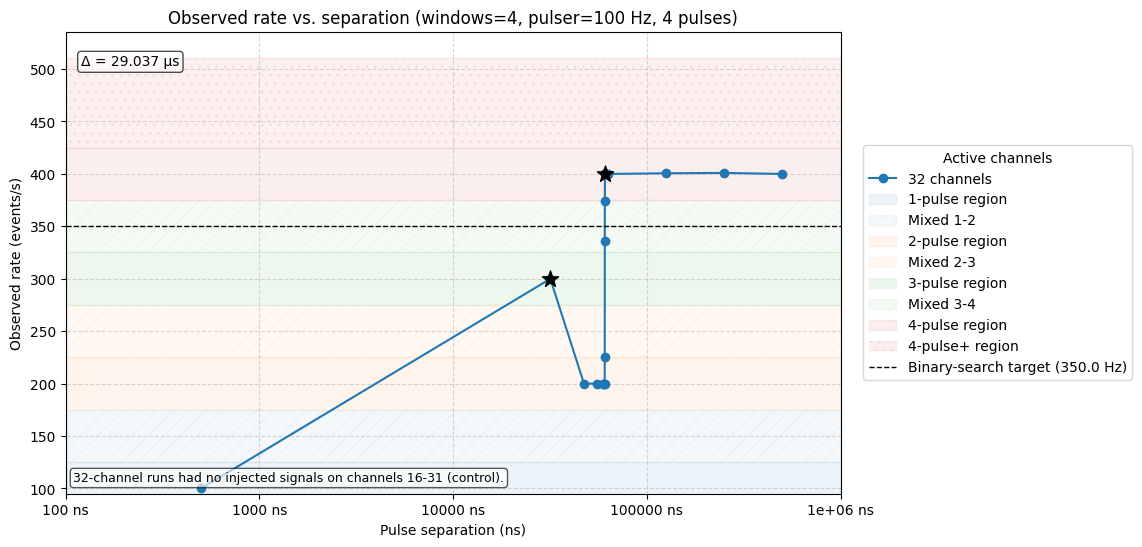

In [3]:

import json
from deadtime_analysis import DeadtimeAnalysis
from pathlib import Path

EST_PATH = Path.cwd().resolve().parent / 'data' / 'estimated_deadtime_all.json'
with EST_PATH.open() as fh:
    estimates = json.load(fh)

# Choose combos where the error bar (response - lower bound) is > 1000 ns
eligible = [
    (e['pulse_rate_hz'], e['num_pulses'], e['channel_count'], e['windows'])
    for e in estimates
    if e.get('min_all_pulses_response_ns') is not None
    and e.get('min_all_pulses_lower_bound_ns') is not None
    and (e['min_all_pulses_response_ns'] - e['min_all_pulses_lower_bound_ns']) > 1000
]
eligible = sorted(set(eligible))
print(f"Eligible combos (error bar > 1000 ns): {len(eligible)}")

# Use eligible combos directly; adjust slicing if you want fewer
EXAMPLE_COMBOS = [
    {"rate": r, "num_pulses": n, "channels": ch, "windows": win}
    for (r, n, ch, win) in eligible
]

# Load full data once
DATA_FILES = [
    Path.cwd().resolve().parent / 'data' / 'combined_deadtime.jsonl',
]
analysis = DeadtimeAnalysis.from_jsonl([str(p) for p in DATA_FILES])

for combo in EXAMPLE_COMBOS:
    rate = combo.get("rate")
    num_pulses = combo.get("num_pulses")
    channels = combo.get("channels")
    windows = combo.get("windows")
    df_filtered = analysis.df.copy()
    if rate is not None:
        df_filtered = df_filtered[df_filtered["pulse_rate_hz"] == rate]
    if num_pulses is not None:
        df_filtered = df_filtered[df_filtered["num_pulses"] == num_pulses]
    if channels is not None:
        df_filtered = df_filtered[df_filtered["channel_count"] == channels]
    if windows is not None:
        df_filtered = df_filtered[df_filtered["windows"] == windows]
    if df_filtered.empty:
        print(f"No data for combo {combo}")
        continue
    match = next(
        (
            e
            for e in estimates
            if e["pulse_rate_hz"] == rate
            and e["num_pulses"] == num_pulses
            and e["channel_count"] == channels
            and e["windows"] == windows
        ),
        None,
    )
    highlights = None
    highlight_text = None
    if match:
        lb = match.get("min_all_pulses_lower_bound_ns")
        resp = match.get("min_all_pulses_response_ns")
        if lb is not None and resp is not None:
            highlights = [lb, resp]
            highlight_text = f"Δ = {(resp - lb)/1000.0:.3f} µs"
    ana = DeadtimeAnalysis(
        df_filtered, single_factor=analysis.single_factor, double_factor=analysis.double_factor
    )
    try:
        ana.plot_rate_vs_separation_by_channels(
            rate, num_pulses=num_pulses, highlight_separations_ns=highlights, highlight_text=highlight_text
        )
        ana.plot_rate_vs_separation_by_windows(
            rate, num_pulses=num_pulses, highlight_separations_ns=highlights, highlight_text=highlight_text
        )
    except ValueError:
        print(f"Plotting failed for combo {combo}")
        continue
